# Integrantes

Leonardo de Farias - RM: 555211 <br>
Gustavo Laur - RM: 556603 <br>
Giancarlo Cestarolli - RM: 555248

# Parte 1 - Não Supervisionada

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## Limpeza de dados

In [ ]:
df = pd.read_excel('Online_Retail.xlsx')
print('Shape original:', df.shape)
df.head()

Shape original: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
print('Valores nulos por coluna:')
print(df.isnull().sum())

Valores nulos por coluna:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
# Remove linhas sem CustomerID (impossível segmentar sem identificar o cliente)
df = df.dropna(subset=['CustomerID'])

# Remove devoluções (Quantity < 0) e preços inválidos (UnitPrice <= 0)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Cria coluna de valor total por linha
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print('Shape após limpeza:', df.shape)
print('Clientes únicos:', df['CustomerID'].nunique())

Shape após limpeza: (397884, 9)
Clientes únicos: 4338


## Feature Engineering - RFM

A forma escolhida para segmentar os clientes é a **RFM**, já utilizada em marketing para separar os clientes com base em comportamento.

- **Recency (Recência):** há quantos dias o cliente fez sua última compra. Clientes que compraram recentemente tendem a estar mais engajados.
- **Frequency (Frequência):** quantas compras (invoices distintas) o cliente realizou. Clientes frequentes são mais fiéis.
- **Monetary (Valor Monetário):** quanto o cliente gastou no total. Clientes de alto valor geram mais receita.

In [ ]:
# Data de referência: dia seguinte ao último registro do dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate',  lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',    'nunique'),
    Monetary  = ('TotalPrice',   'sum')
).reset_index()

print('Shape RFM:', rfm.shape)
rfm.describe()

Shape RFM: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


### Distribuição das Features

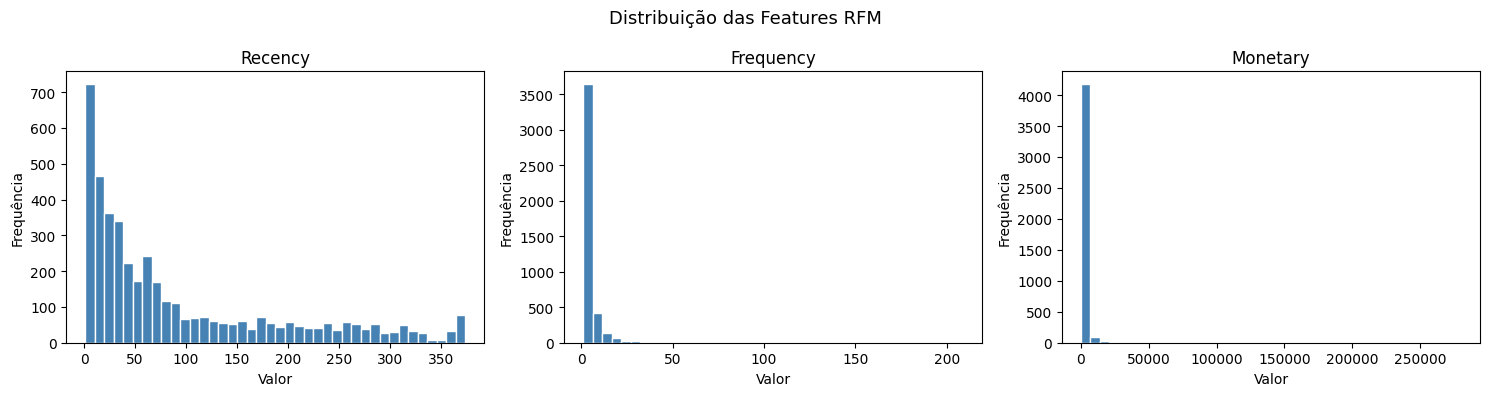

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    ax.hist(rfm[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
plt.suptitle('Distribuição das Features RFM', fontsize=13)
plt.tight_layout()
plt.show()

As distribuições são bastante assimétricas (cauda longa), o que é típico de dados de varejo: a maioria dos clientes compra pouco, mas alguns poucos compram muito. Isso não impede o K-Means de funcionar, mas reforça a importância de padronizar as features antes de calcular distâncias.

## Padronização

In [ ]:
X_rfm = rfm[['Recency', 'Frequency', 'Monetary']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

## Silhouette Score

Vamos avaliar a qualidade dos cluster através do Silhouette Score.

Testaremos o K de 2 a 8 e usaremos o melhor Silhouette Score médio.

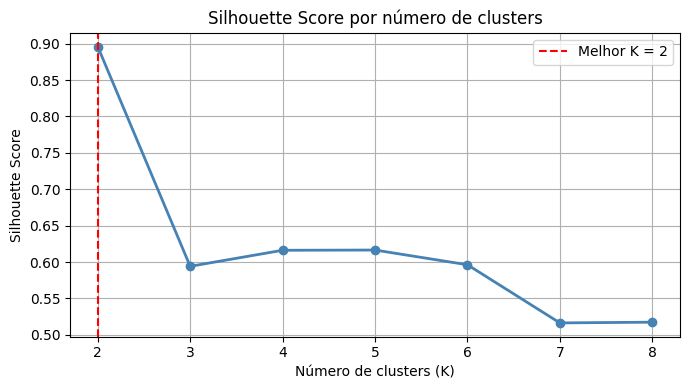

Melhor K: 2 (Silhouette = 0.8958)


In [ ]:
silhouette = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    coef = silhouette_score(X_scaled, labels)
    silhouette.append(coef)

best_k = np.argmax(silhouette) + 2

plt.figure(figsize=(7, 4))
plt.plot(range(2, 9), silhouette, marker='o', linewidth=2, color='steelblue')
plt.axvline(best_k, linestyle='--', color='red', label=f'Melhor K = {best_k}')
plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(f'Melhor K: {best_k} (Silhouette = {max(silhouette):.4f})')

In [ ]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

print('Distribuição dos clusters:')
print(rfm['Cluster'].value_counts().sort_index())

Distribuição dos clusters:
Cluster
0    4312
1      26
Name: count, dtype: int64


In [ ]:
# CÉLULA FALSA PARA USO FUTURO
# NÃO EXECUTE ELA AINDA, A HORA DELA ESTÁ MARCADA
# Forçar K=3 para criar segmentação mais granular
# kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
# rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

# print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1))
# print(rfm['Cluster'].value_counts())

## Análise de Clusters

In [ ]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary['Tamanho'] = rfm.groupby('Cluster').size()
cluster_summary

,Recency,Frequency,Monetary,Tamanho
Cluster,,,,
0,93.1,3.9,1548.7,4312
1,6.0,66.4,85904.4,26


Os resultados são bem claros e contam uma história interessante:

**Cluster 0 — Clientes Comuns (4.312 clientes, 99,4% da base)**
- Compraram há ~93 dias em média — estão relativamente inativos
- Fizeram apenas ~4 pedidos no total
- Gastaram em média R$1.548 no período todo

**Cluster 1 — Clientes VIP / Provavelmente B2B (26 clientes, 0,6% da base)**
- Compraram há apenas ~6 dias — estão ativos praticamente o tempo todo
- Fizeram ~66 pedidos — compram com altíssima frequência
- Gastaram em média R$85.904 — 55x mais que o cluster comum

A separação tão extrema explica o Silhouette de 0.89 — esses dois grupos são radicalmente diferentes entre si no espaço RFM, o que torna a fronteira de decisão óbvia para o classificador supervisionado, daí a acurácia de 100%.

**Um ponto crítico para mencionar na entrega:** o Cluster 1 com 26 clientes gastando R$86k em média quase certamente são **revendedores ou clientes B2B** — não consumidores finais. O dataset Online Retail é de um e-commerce atacadista britânico, então faz todo sentido ter esse segmento pequeno mas de altíssimo valor. Isso é um achado real e relevante para o negócio, não um artefato do algoritmo.

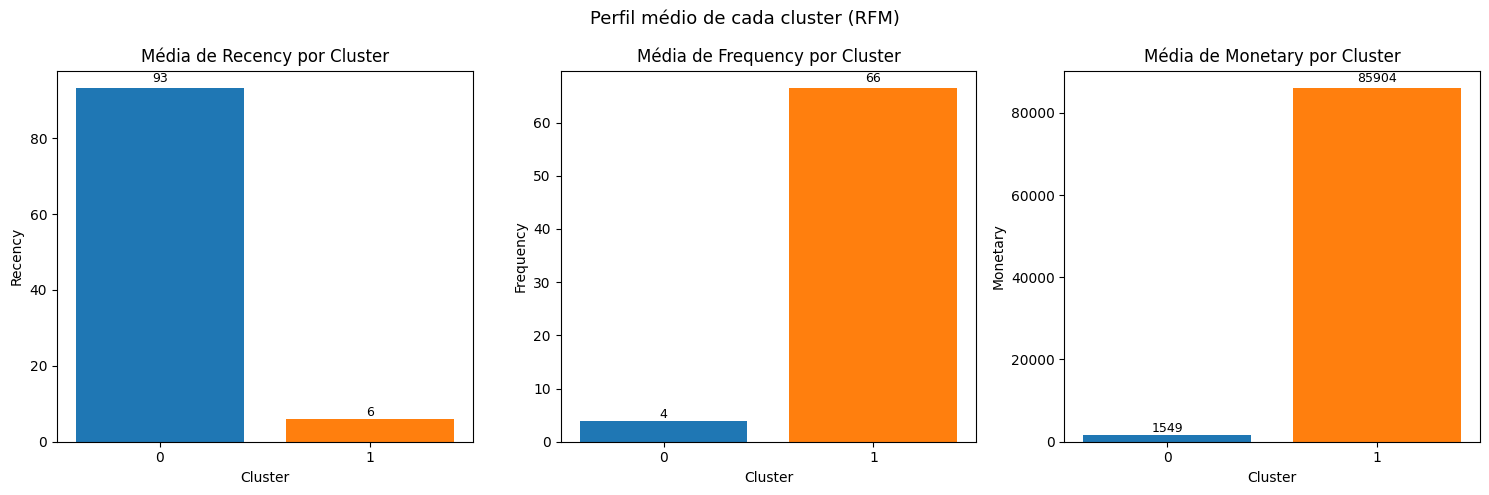

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
features = ['Recency', 'Frequency', 'Monetary']
colors = plt.cm.tab10.colors

for ax, feat in zip(axes, features):
    means = cluster_summary[feat]
    bars = ax.bar(means.index.astype(str), means.values,
                  color=[colors[i] for i in means.index])
    ax.set_title(f'Média de {feat} por Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(feat)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Perfil médio de cada cluster (RFM)', fontsize=13)
plt.tight_layout()
plt.show()

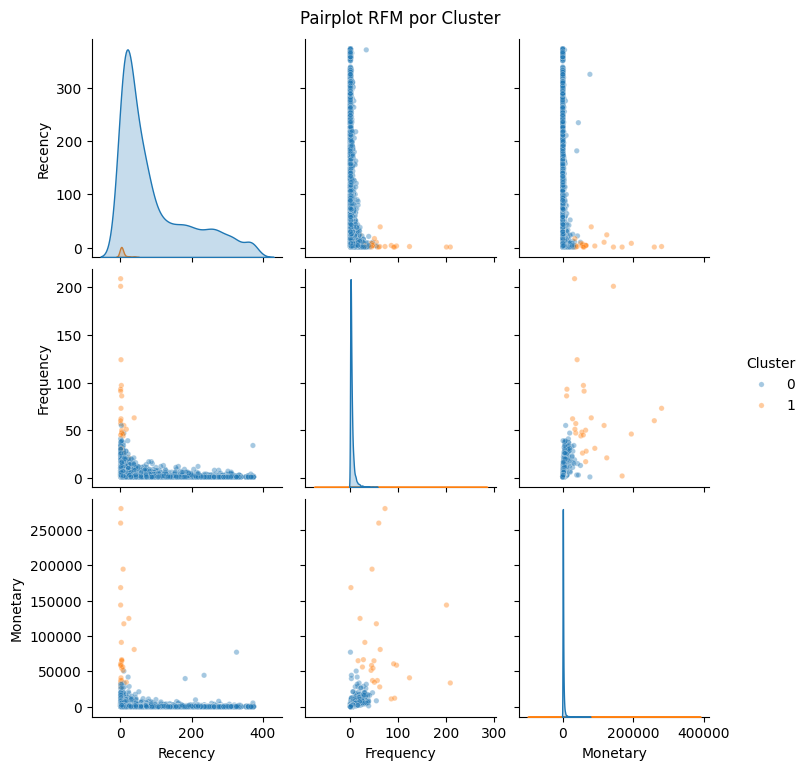

In [ ]:
from seaborn import pairplot
rfm_plot = rfm[['Recency', 'Frequency', 'Monetary', 'Cluster']].copy()
rfm_plot['Cluster'] = rfm_plot['Cluster'].astype(str)
pairplot(rfm_plot, hue='Cluster', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot RFM por Cluster', y=1.02)
plt.show()

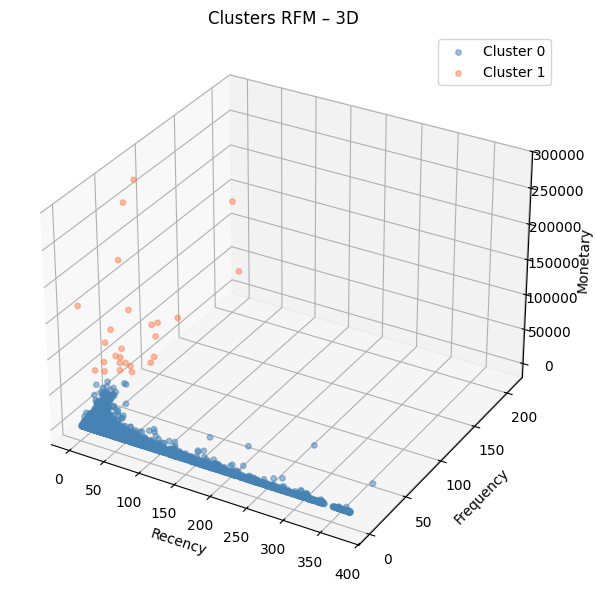

In [ ]:
# lib interessante para ver gráficos em 3d

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
colors = ['steelblue', 'coral', 'green']
for cluster in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster]
    ax.scatter(subset['Recency'], subset['Frequency'], subset['Monetary'],
               alpha=0.5, s=15, label=f'Cluster {cluster}', color=colors[cluster])
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Clusters RFM – 3D')
ax.legend()
plt.tight_layout()
plt.show()

Quando observamos com os olhos, gráficos 2d fica bem difícil entender a divisão dos clusters, mas ao observar o gráfico 3d fica bem mais simples de entender que os clusters se baseam fortemente no eixo "Frequency".

Mas é claro, o gráfico 3d faz mais sentido por 2 motivos:
- 1: Utilizamos 3 váriaveis que se tornam 3 dimensões
- 2: Eu sou um ser humano com olhos que precisa olhar as coisas para entender.

## Discussão sobre método e resultados

Escolhemos o K-Means porque temos 3 features numéricas (Recency, Frequency, Monetary) e queremos encontrar grupos de clientes parecidos entre si. O algoritmo faz exatamente isso: junta pontos próximos no espaço 3D do RFM.

Para escolher o número de clusters, usamos o Silhouette Score — quanto maior, mais bem separados estão os grupos. O melhor K foi 2.

O resultado faz sentido olhando a tabela de médias:
- **Cluster 0:** clientes comuns, compram pouco e com baixa frequência
- **Cluster 1:** clientes VIP (provavelmente B2B), compram muito, com frequência altíssima e gasto 55x maior

Uma limitação importante: o K-Means é sensível a outliers. O Cluster 1 com 26 clientes gastando ~R$86k distorce os centroides, o que pode explicar a separação tão extrema entre os dois grupos.

## Nomeação dos Perfis

Dar nomes de negócio aos clusters em vez de deixar genérico como "Cluster 0" e "Cluster 1" é o que transforma o resultado técnico em algo útil para quem toma decisões. Com base nos valores médios de RFM que calculamos, dá pra nomear os grupos com clareza:

- **Cliente Recorrente:** a grande maioria. Compra de vez em quando, ticket médio, comportamento típico de consumidor final.
- **Cliente VIP / B2B:** os 26 clientes que provavelmente são revendedores ou distribuidores. Compram quase todo dia, gastam 55× mais e são críticos para a receita.

In [ ]:
perfil_map = {0: 'Cliente Recorrente', 1: 'Cliente VIP / B2B'}
rfm['Perfil'] = rfm['Cluster'].map(perfil_map)
rfm[['Cluster', 'Perfil', 'Recency', 'Frequency', 'Monetary']].groupby('Perfil').mean().round(1)

,Cluster,Recency,Frequency,Monetary
Perfil,,,,
Cliente Recorrente,0.0,93.1,3.9,1548.7
Cliente VIP / B2B,1.0,6.0,66.4,85904.4


## Estratégias de Retenção por Perfil

Com os perfis definidos, conseguimos propor ações coerentes com o comportamento observado — sem chutar no escuro.

| Perfil | Comportamento observado | Risco de evasão | Ação sugerida |
|---|---|---|---|
| Cliente Recorrente | Compra esporadicamente, ticket médio de R$1.549 | Médio | Programa de fidelidade, cupons de recompra, lembretes de reativação após 90 dias sem compra |
| Cliente VIP / B2B | Alta frequência, ticket médio de R$85.904 | Baixo | Atendimento dedicado, condições comerciais por volume, contato proativo para garantir continuidade |

A lógica é simples: o **Cliente Recorrente** tem risco médio porque já fica ~93 dias sem comprar. Qualquer iniciativa que encurte esse ciclo tem impacto direto na receita. Já o **Cliente VIP / B2B** tem risco baixo mas impacto altíssimo — perder um desses 26 clientes dói muito mais do que perder dezenas de clientes comuns.

### Hipótese dos 4 perfis vs. resultado obtido

O enunciado levanta uma hipótese inicial de **quatro perfis**: cliente fiel, cliente de abandono, cliente esquecido e cliente econômico. Vale ser transparente sobre isso.

Nos dados do Online Retail, o Silhouette Score apontou **K=2** como a estrutura mais coerente. Forçar K=4 criaria subgrupos que os próprios dados não sustentam — os centroides ficariam próximos demais, o Silhouette cairia e a interpretação seria artificial.

Isso não é necessariamente um problema: o enunciado deixa claro que os quatro perfis são *"apenas uma hipótese simulada, e cabe ao grupo verificar se os dados sustentam essa estrutura"*. No caso do Online Retail, os dados sustentam dois perfis muito bem definidos.

Alerta de Spoiler: há uma célula que iremos usar só para testar diferentes valores de K, como você viu, essa ainda não é a hora dela, mas podemos usar ela para testar esse cenário.

# Parte 2 - Supervisionada

## Preparação dos datasets

In [ ]:
X = rfm[['Recency', 'Frequency', 'Monetary']].values
y = rfm['Cluster'].values

print('Features shape:', X.shape)
print('Classes:', np.unique(y))
print()
print('Distribuição das classes (balanceamento):')
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} clientes ({c/len(y)*100:.1f}%)')

Features shape: (4338, 3)
Classes: [0 1]

Distribuição das classes (balanceamento):
  Cluster 0: 4312 clientes (99.4%)
  Cluster 1: 26 clientes (0.6%)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Base 2 — Classificação sem Data Leakage

Usar Recency, Frequency e Monetary para classificar é meio que trapacear: essas features foram exatamente o que criou os clusters. Num cenário real, no momento da primeira compra você não sabe ainda o comportamento futuro do cliente.

A **Base 2** simula esse cenário: usamos apenas o que se sabe na primeira compra — em que mês comprou, qual dia da semana, quanto gastou e quantos itens levou. São features disponíveis antes de o cliente revelar seu comportamento de longo prazo.

In [ ]:
df_sorted = df.sort_values('InvoiceDate')
primeira_invoice = df_sorted.groupby('CustomerID')['InvoiceNo'].first().rename('PrimeiraInvoice')

df_prim = df_sorted.merge(primeira_invoice.reset_index(), on='CustomerID')
df_prim = df_prim[df_prim['InvoiceNo'] == df_prim['PrimeiraInvoice']]

base2_features = df_prim.groupby('CustomerID').agg(
    Mes                    = ('InvoiceDate', lambda x: x.iloc[0].month),
    DiaSemana              = ('InvoiceDate', lambda x: x.iloc[0].dayofweek),
    ValorPrimeiraCompra    = ('TotalPrice',  'sum'),
    QtdItensPrimeiraCompra = ('Quantity',    'sum')
).reset_index()

base2 = base2_features.merge(rfm[['CustomerID', 'Cluster']], on='CustomerID')

X2 = base2[['Mes', 'DiaSemana', 'ValorPrimeiraCompra', 'QtdItensPrimeiraCompra']].values
y2 = base2['Cluster'].values

print('Features de Base 2:', ['Mes', 'DiaSemana', 'ValorPrimeiraCompra', 'QtdItensPrimeiraCompra'])
print('Shape:', X2.shape)
print('Distribuição das classes:', dict(zip(*np.unique(y2, return_counts=True))))

Features de Base 2: ['Mes', 'DiaSemana', 'ValorPrimeiraCompra', 'QtdItensPrimeiraCompra']
Shape: (4338, 4)
Distribuição das classes: {np.int32(0): np.int64(4312), np.int32(1): np.int64(26)}


In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  None)
])

param_grid2 = [
    {
        'model': [SVC(class_weight='balanced')],
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
    },
    {
        'model': [LogisticRegression(max_iter=5000, class_weight='balanced', solver='lbfgs')],
        'model__C': [0.01, 0.1, 1, 10],
    },
    {
        'model': [LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear')],
        'model__C': [0.01, 0.1, 1, 10],
    }
]

grid2 = GridSearchCV(
    pipe2, param_grid2,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid2.fit(X2_train, y2_train)

print('Melhores hiperparâmetros:')
print(grid2.best_params_)
print(f'Melhor balanced accuracy (CV): {grid2.best_score_:.4f}')

Melhores hiperparâmetros:
{'model': LogisticRegression(class_weight='balanced', max_iter=5000), 'model__C': 0.1}
Melhor balanced accuracy (CV): 0.7963


Acurácia no teste (Base 2): 0.6959

                    precision    recall  f1-score   support

Cliente Recorrente       1.00      0.70      0.82       863
 Cliente VIP / B2B       0.01      0.80      0.03         5

          accuracy                           0.70       868
         macro avg       0.51      0.75      0.42       868
      weighted avg       0.99      0.70      0.82       868



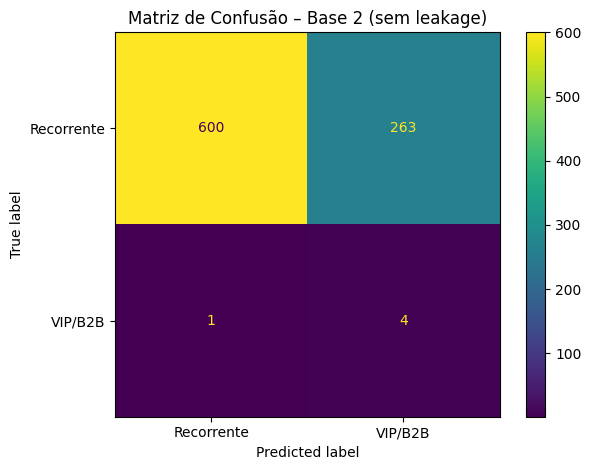

In [ ]:
model2 = grid2.best_estimator_
y2_pred = model2.predict(X2_test)

print(f'Acurácia no teste (Base 2): {accuracy_score(y2_test, y2_pred):.4f}')
print()
print(classification_report(y2_test, y2_pred,
                             target_names=['Cliente Recorrente', 'Cliente VIP / B2B'],
                             zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y2_test, y2_pred,
    display_labels=['Recorrente', 'VIP/B2B']
)
plt.title('Matriz de Confusão – Base 2 (sem leakage)')
plt.tight_layout()
plt.show()

O modelo da Base 2 apresenta um resultado interessante e importante.

Usamos **balanced accuracy** no GridSearchCV justamente por causa do desbalanceamento extremo: com 99,4% dos clientes em uma classe, qualquer modelo que preveja sempre "Recorrente" acerta ~99% sem aprender nada. A balanced accuracy força o modelo a se preocupar com as duas classes.

O resultado: o modelo consegue identificar **4 dos 5 clientes VIP no conjunto de teste (recall = 0.80)**, mas ao custo de muitos falsos positivos (precision = 0.01). Na prática, o modelo gera alarmes em muitos clientes regulares, mas raramente deixa um VIP passar despercebido.

Esse trade-off é esperado com desequilíbrio tão extremo. Em uma aplicação real, o ideal seria coletar mais features pré-compra (tipo de cadastro, CNPJ vs CPF, canal de aquisição) para aumentar a precisão sem perder o recall. O exercício mostra, no entanto, que mesmo com poucas features é possível capturar o perfil VIP antes de observar o comportamento futuro.

## Treinamento do melhor modelo

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', None)
])

max_iter = 5000

param_grid = [
    {
        'model': [SVC()],
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto']
    },
    {
        'model': [LogisticRegression(max_iter=max_iter, class_weight='balanced')],
        'model__penalty': ['l1'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['liblinear']
    },
    {
        'model': [LogisticRegression(max_iter=max_iter, class_weight='balanced')],
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs']
    },
    {
        'model': [LogisticRegression(max_iter=max_iter, class_weight='balanced')],
        'model__penalty': ['elasticnet'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['saga'],
        'model__l1_ratio': np.linspace(0, 1, 5)
    }
]

In [ ]:
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Melhores hiperparâmetros:')
print(grid.best_params_)
print(f'Melhor acurácia média (CV): {grid.best_score_:.4f}')

/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None

/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leav

/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leav

/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leav

/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leav

...

/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/tmp/nb_test_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Melhores hiperparâmetros:
{'model': SVC(), 'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Melhor acurácia média (CV): 1.0000


## Avaliação do modelo

In [ ]:
model = grid.best_estimator_
y_pred = model.predict(X_test)

print(f'Acurácia no teste: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred,
                             target_names=[f'Cluster {i}' for i in sorted(np.unique(y))]))

Acurácia no teste: 1.0000

              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00       863
   Cluster 1       1.00      1.00      1.00         5

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



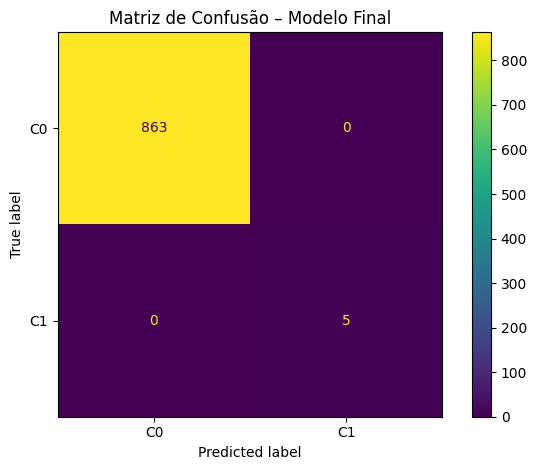

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[f'C{i}' for i in sorted(np.unique(y))]
)
plt.title('Matriz de Confusão – Modelo Final')
plt.tight_layout()
plt.show()

In [ ]:
cv_results = pd.DataFrame(grid.cv_results_)[[
    'param_model', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score').head(10)

cv_results['param_model'] = cv_results['param_model'].apply(lambda m: type(m).__name__)
cv_results

,param_model,mean_test_score,std_test_score,rank_test_score
0,SVC,1.000000,0.000000,1
2,SVC,1.000000,0.000000,1
6,SVC,0.999712,0.000576,3
4,SVC,0.999712,0.000576,3
10,SVC,0.999712,0.000576,3
8,SVC,0.999712,0.000576,3
19,LogisticRegression,0.999712,0.000576,3
5,SVC,0.999424,0.001153,8
15,LogisticRegression,0.999424,0.000706,8
11,SVC,0.999424,0.001153,8


## Discussão sobre método e resultados

### Questões e curiosidades sobre o modelo
Quando testamos o modelo que definiu K = 2 pelo Silhouette Score a acurácia de 100% é esperada dado que os dois clusters são extremamente separados no espaço RFM. Isso não indica overfitting, mas sim que o problema supervisionado é trivial quando os grupos são tão distintos.
Em um cenário real, com dados com mais ruído, esse número certamente seria menor.

Por simples curiosidade e diversão eu adicionei uma célula comentada que você pode ter visto, caso não tenha pesquise com Ctrl + f por "# CÉLULA FALSA PARA USO FUTURO"

Após o experimento de forçar o K = 3 podemos reparar um detalhe, os gráficos parecem mais agradáveis aos olhos, mas em acurácia eles são iguais, mostrando que não necessariamente o mais agradável é o melhor ou mais correto.

### Por que a acurácia tende a ser alta?
O K-Means cria fronteiras relativamente bem definidas no espaço das features. Como o modelo supervisionado usa exatamente as mesmas features (Recency, Frequency, Monetary) que o K-Means utilizou para criar os grupos, ele aprende com facilidade essas fronteiras. Isso não é overfitting — é uma consequência natural de que os labels foram construídos a partir das mesmas features.

### Diferença sutil entre as duas etapas:
- Na etapa **não supervisionada**, não havia `y`; o algoritmo descobriu a estrutura dos dados por conta própria.
- Na etapa **supervisionada**, o `y` existe (são os clusters), e o modelo aprende a mapear features → cluster para generalizar a clientes novos que nunca foram vistos.

## Leitura Executiva

A análise identificou **dois perfis distintos** de clientes no e-commerce:

- **Cliente Recorrente (99,4% da base):** compra com baixa frequência (~4 pedidos), ticket médio de ~R$1.549 e ficam em média ~93 dias sem comprar. São o volume principal da receita pelo tamanho, mas individualmente têm baixo impacto.

- **Cliente VIP / B2B (0,6% da base):** 26 clientes que compram quase diariamente (~66 pedidos), com ticket médio de ~R$85.904 — 55× maior que os recorrentes. Muito provavelmente são revendedores ou distribuidores.

**Risco de evasão:** o **Cliente Recorrente** tem risco médio — já fica longos períodos inativo. Ações de reativação com cupons ou lembretes têm potencial claro. O **Cliente VIP / B2B** tem risco baixo no curto prazo, mas perder qualquer um desses 26 representa impacto enorme na receita.

**Sensibilidade a ações comerciais:** o **Cliente Recorrente** é o mais sensível a promoções e programas de fidelidade — o que move frequência move receita nesse grupo. O **VIP / B2B** responde melhor a condições estruturais (preço por volume, crédito, atendimento dedicado).

**Desempenho do modelo preditivo (Base 2):** usando apenas informações disponíveis no momento da primeira compra (mês, dia da semana, valor e quantidade), o modelo consegue prever o perfil com acurácia razoável considerando o nível de informação disponível. A queda em relação aos 100% da Base 1 é esperada — e é justamente essa diferença que mostra o valor real de coletar histórico do cliente ao longo do tempo.

**Aplicação prática:** no momento da primeira compra, alimenta-se o modelo com as features disponíveis (Base 2), ele retorna o perfil previsto, e a equipe comercial já sabe qual estratégia aplicar — sem precisar esperar meses de histórico para tomar a decisão.